In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [39]:
df = pd.read_csv(r"C:\projects\titanic\train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [41]:
df.shape

(891, 12)

In [42]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [43]:
print(f"число пропусков по столбцам: \n{df.isna().sum()}")

число пропусков по столбцам: 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [44]:
print("количество уникальных значений в каждом столбце")
print(df.nunique())

количество уникальных значений в каждом столбце
PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64


категориальные: Survived, Pclass, Sex, SibSp, Parch, Cabin, Embarked

In [45]:
print("распределение классов по Survived")
df["Survived"].value_counts(normalize=True)

распределение классов по Survived


Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

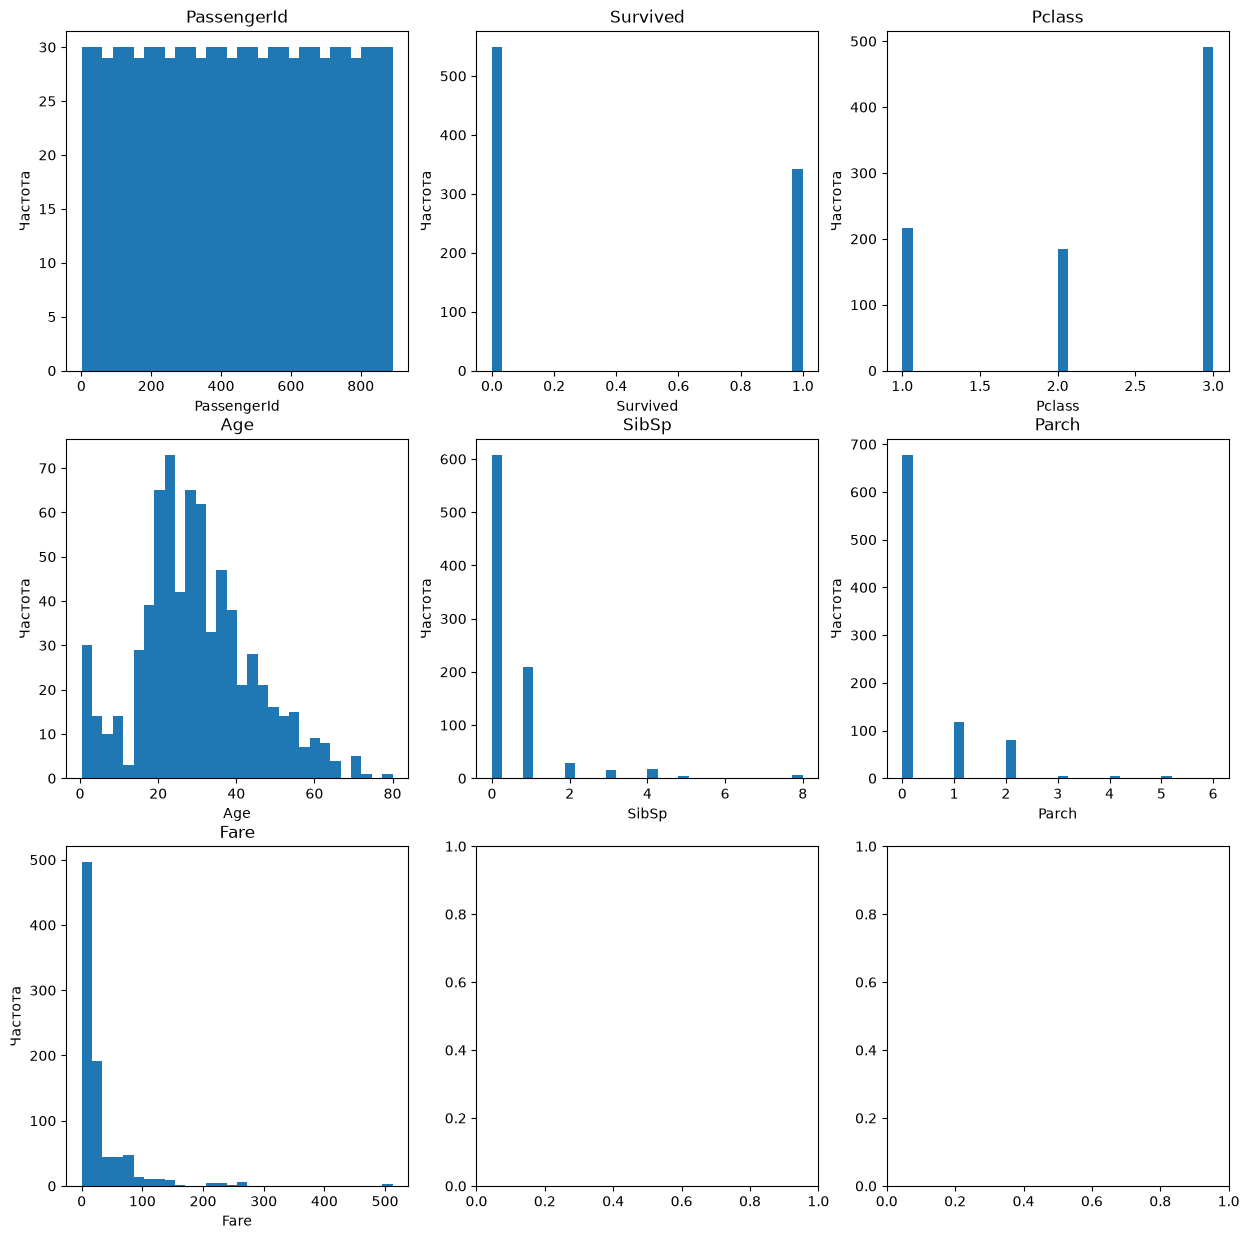

In [46]:
# гистограммы распределения числовых признаков
# числовые признаки
num_cols = df.select_dtypes(include="number").columns
n = len(num_cols)
ncols = 3
nrows = (n+ncols-1)//ncols

fig, axes = plt.subplots(nrows, ncols,figsize = (15, 5*nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins = 30)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Частота")

plt.show()

In [47]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


In [48]:
df["Cabin"].head(15)

0      NaN
1      C85
2      NaN
3     C123
4      NaN
5      NaN
6      E46
7      NaN
8      NaN
9      NaN
10      G6
11    C103
12     NaN
13     NaN
14     NaN
Name: Cabin, dtype: str

In [49]:
# убераем ненужные столбцы
trash_cols = ["PassengerId","Ticket", "Cabin"]
df = df.drop(columns=trash_cols)
df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='str')

In [50]:
df["Title"] = df["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)
df["Title"].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [51]:
counts = df["Title"].value_counts()
rare_titles = counts[counts<3].index
df["Title"] = df["Title"].replace(rare_titles, "Rare")
df["Title"].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       14
Dr          7
Rev         6
Name: count, dtype: int64

In [52]:
df['Age'] = df.groupby(['Title', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

In [53]:
df.isna().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    2
Title       0
dtype: int64

In [54]:
df.loc[df['Embarked'].isnull(), 'Embarked'] = 'C'

C:\Users\user\AppData\Local\Temp\ipykernel_12316\3260333409.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2')


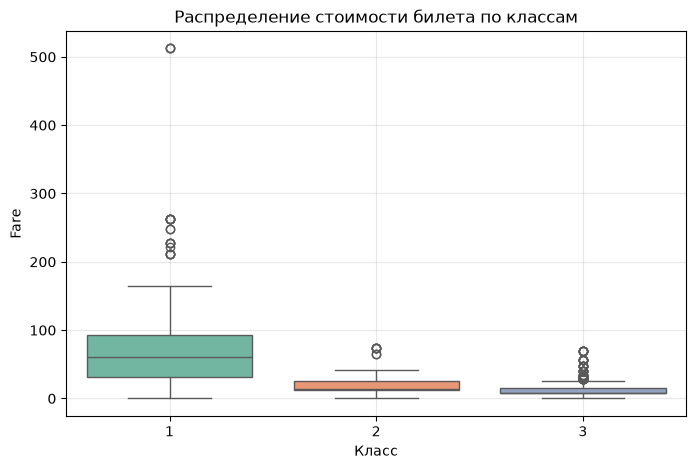

In [55]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Pclass', y='Fare', palette='Set2')
plt.title('Распределение стоимости билета по классам')
plt.xlabel('Класс')
plt.ylabel('Fare')
plt.grid(True, alpha=0.3)
plt.show()

In [56]:
df["Pclass"].head()

0    3
1    1
2    3
3    1
4    3
Name: Pclass, dtype: int64

In [57]:
condition1 = (df["Pclass"] == 1) & (df["Fare"] > 200)
condition2 = (df["Pclass"] == 2) & (df["Fare"] > 60)
condition3 = (df["Pclass"] == 3) & (df["Fare"] > 30)

outliers = df.loc[condition1 | condition2 | condition3]

In [58]:
outliers

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title
13,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,31.2750,S,Mr
25,1,3,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,1,5,31.3875,S,Mrs
27,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,263.0000,S,Mr
50,0,3,"Panula, Master. Juha Niilo",male,7.0,4,1,39.6875,S,Master
59,0,3,"Goodwin, Master. William Frederick",male,11.0,5,2,46.9000,S,Master
...,...,...,...,...,...,...,...,...,...,...
826,0,3,"Lam, Mr. Len",male,26.0,0,0,56.4958,S,Mr
838,1,3,"Chip, Mr. Chang",male,32.0,0,0,56.4958,S,Mr
846,0,3,"Sage, Mr. Douglas Bullen",male,26.0,8,2,69.5500,S,Mr
850,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,31.2750,S,Master


In [59]:
df["Family"] = df["SibSp"]+df["Parch"]+1

In [60]:
df["is_alone"] = np.where((df["SibSp"]==0) & (df["Parch"]==0),1,0)

In [61]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['child', 'teen', 'young', 'adult', 'senior']

df["AgeGroup"] = pd.cut(df["Age"],bins = bins,labels=labels)

In [62]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Family,is_alone,AgeGroup
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,Mr,2,0,young
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,Mrs,2,0,adult
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,Miss,1,1,young
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Mrs,2,0,young
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,Mr,1,1,young


In [63]:
df["FarePerPerson"] = df["Fare"]/df["Family"]

с кодом ниже нужно разобраться

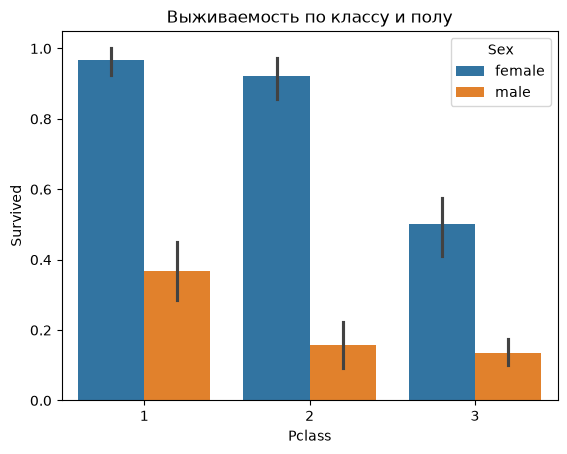

In [28]:
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex')
plt.title('Выживаемость по классу и полу')
plt.show()

In [32]:

# Создаём возрастные группы, если их ещё нет
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Ребёнок', 'Подросток', 'Молодой', 'Взрослый', 'Пожилой']
)

result = (
    df.groupby(['Sex', 'Pclass', 'AgeGroup'], observed=True)
      .agg(
          Выживаемость=('Survived', 'mean'),
          Количество=('Survived', 'size')
      )
      .reset_index()
)

result['Выживаемость_%'] = (result['Выживаемость'] * 100).round(1)
result

,Sex,Pclass,AgeGroup,Выживаемость,Количество,Выживаемость_%
0,female,1,Ребёнок,0.000000,1,0.0
1,female,1,Подросток,1.000000,10,100.0
2,female,1,Молодой,0.972973,37,97.3
3,female,1,Взрослый,0.977273,44,97.7
4,female,1,Пожилой,1.000000,2,100.0
5,female,2,Ребёнок,1.000000,8,100.0
6,female,2,Подросток,1.000000,6,100.0
7,female,2,Молодой,0.928571,42,92.9
8,female,2,Взрослый,0.850000,20,85.0
9,female,3,Ребёнок,0.478261,23,47.8


In [33]:
pivot = df.pivot_table(
    values='Survived',
    index='Sex',
    columns='Pclass',
    aggfunc='mean'
)

pivot

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


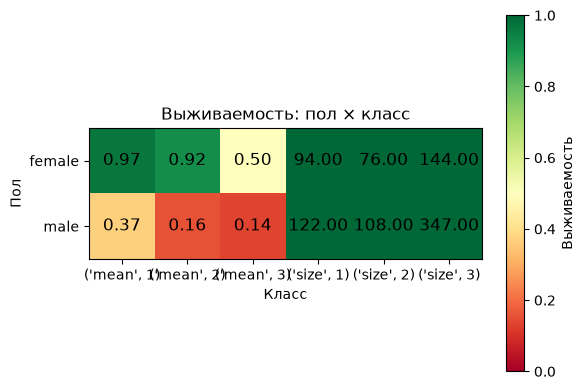

In [35]:
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=0, vmax=1)

# Подписи осей
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_xticklabels(pivot.columns)
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Класс')
ax.set_ylabel('Пол')
ax.set_title('Выживаемость: пол × класс')

# Числа в клетках
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.2f}',
                ha='center', va='center',
                color='black', fontsize=12)

fig.colorbar(im, ax=ax, label='Выживаемость')
plt.tight_layout()
plt.show()

In [36]:
df["Title"].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       14
Dr          7
Rev         6
Name: count, dtype: int64

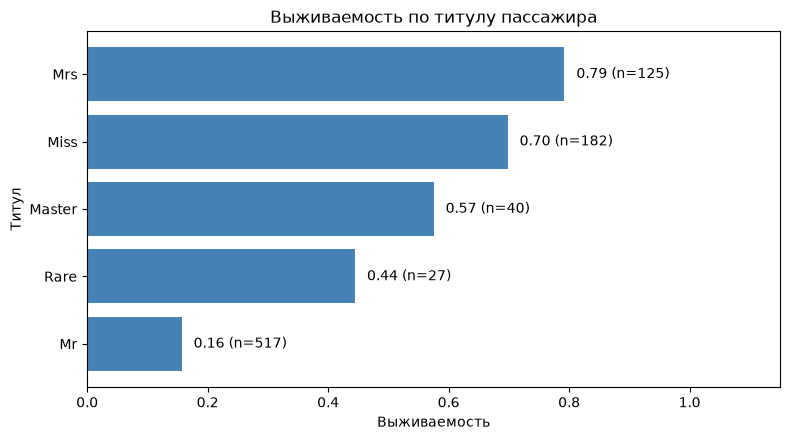

In [37]:
# Приводим редкие титулы к 'Rare' (оставляем только Mr, Miss, Mrs, Master)
rare_titles = ['Dr', 'Rev', 'Lady', 'Countess', 'Capt', 'Col', 'Don',
               'Major', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

# Выживаемость по титулу
title_surv = (
    df.groupby('Title')['Survived']
      .agg(Выживаемость='mean', Количество='size')
      .sort_values('Выживаемость')
)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(title_surv.index, title_surv['Выживаемость'],
               color='steelblue')

# Подписи значений справа от столбиков
for bar, mean, size in zip(bars,
                           title_surv['Выживаемость'],
                           title_surv['Количество']):
    ax.text(bar.get_width() + 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{mean:.2f} (n={size})',
            va='center', fontsize=10)

ax.set_xlim(0, 1.15)
ax.set_xlabel('Выживаемость')
ax.set_ylabel('Титул')
ax.set_title('Выживаемость по титулу пассажира')
plt.tight_layout()
plt.show()

In [64]:
# family_size = SibSp + Parch + 1 (сам пассажир)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

family_surv = (
    df.groupby('FamilySize')['Survived']
      .agg(Выживаемость='mean', Количество='size')
      .reset_index()
)

# Находим размер семьи с максимальной выживаемостью
best = family_surv.loc[family_surv['Выживаемость'].idxmax()]
print(f"Максимум выживаемости: FamilySize={int(best['FamilySize'])}, "
      f"выживаемость={best['Выживаемость']:.2%}, n={int(best['Количество'])}")

family_surv

Максимум выживаемости: FamilySize=4, выживаемость=72.41%, n=29


,FamilySize,Выживаемость,Количество
0,1,0.303538,537
1,2,0.552795,161
2,3,0.578431,102
3,4,0.724138,29
4,5,0.200000,15
5,6,0.136364,22
6,7,0.333333,12
7,8,0.000000,6
8,11,0.000000,7


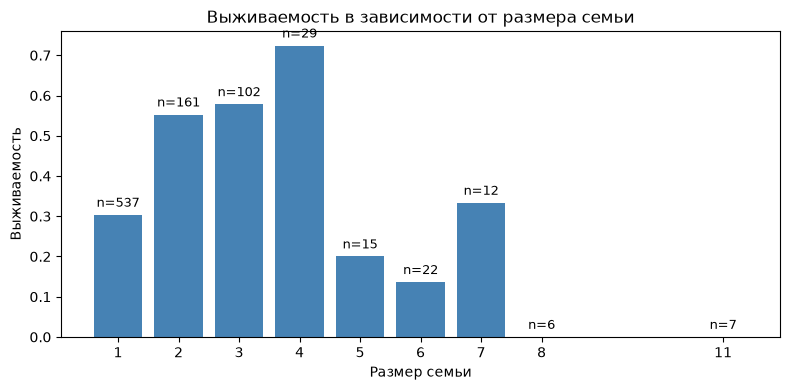

In [65]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(family_surv['FamilySize'], family_surv['Выживаемость'],
       color='steelblue')
ax.set_xlabel('Размер семьи')
ax.set_ylabel('Выживаемость')
ax.set_title('Выживаемость в зависимости от размера семьи')
ax.set_xticks(family_surv['FamilySize'])

# Подписи n над столбиками
for x, mean, size in zip(family_surv['FamilySize'],
                         family_surv['Выживаемость'],
                         family_surv['Количество']):
    ax.text(x, mean + 0.02, f'n={size}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

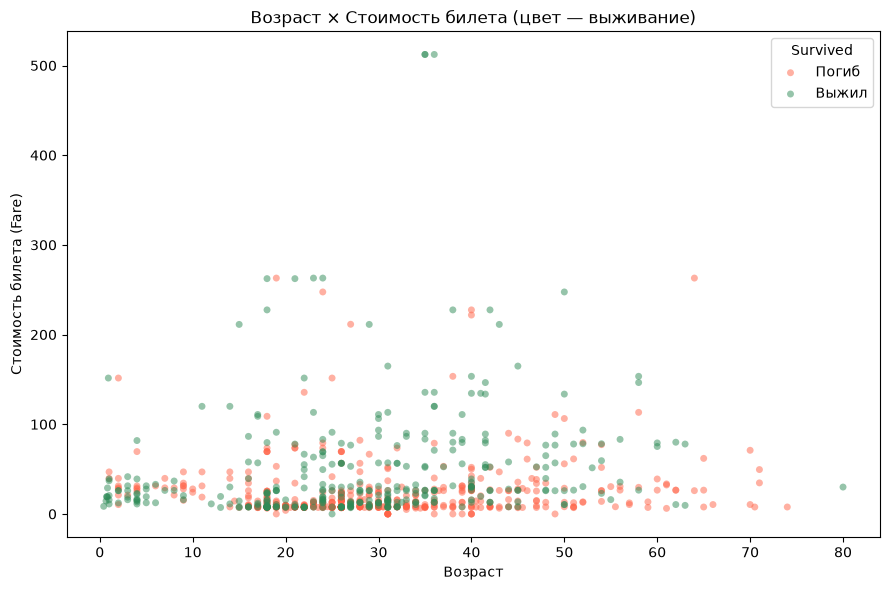

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

# Два слоя — выжившие и погибшие, чтобы была нормальная легенда
for survived, color, label in [(0, 'tomato', 'Погиб'),
                               (1, 'seagreen', 'Выжил')]:
    sub = df[df['Survived'] == survived]
    ax.scatter(sub['Age'], sub['Fare'],
               c=color, alpha=0.5, s=25,
               edgecolors='none', label=label)

ax.set_xlabel('Возраст')
ax.set_ylabel('Стоимость билета (Fare)')
ax.set_title('Возраст × Стоимость билета (цвет — выживание)')
ax.legend(title='Survived')
plt.tight_layout()
plt.show()

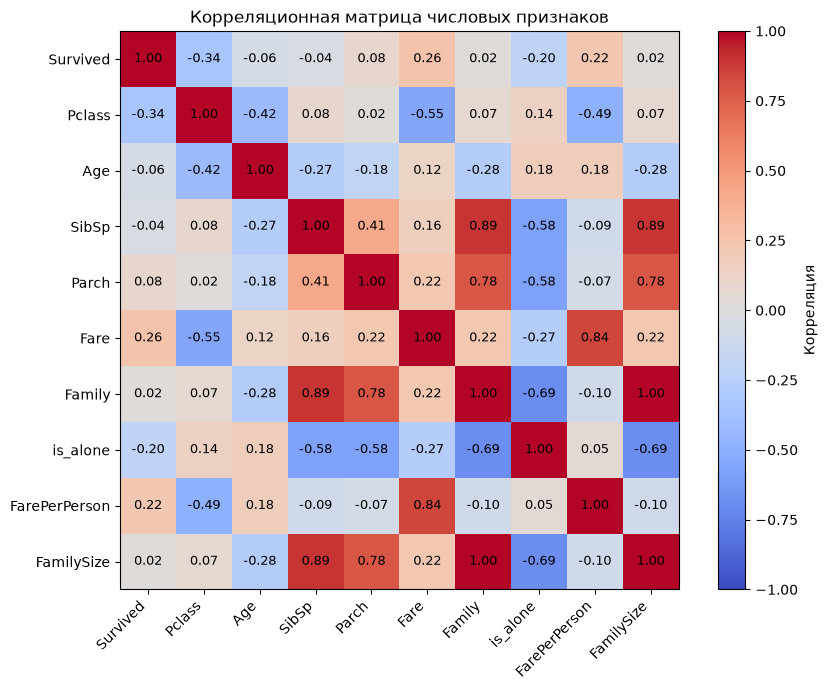

In [67]:
# Берём только числовые колонки
num_df = df.select_dtypes(include=np.number)

corr = num_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)

# Подписи осей
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

# Числа в клетках
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        val = corr.values[i, j]
        ax.text(j, i, f'{val:.2f}',
                ha='center', va='center',
                color='black', fontsize=9)

ax.set_title('Корреляционная матрица числовых признаков')
fig.colorbar(im, ax=ax, label='Корреляция')
plt.tight_layout()
plt.show()

In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df["Fare"].skew()

np.float64(4.787316519674893)

In [71]:
df = pd.get_dummies(df, columns=["Embarked"]) 

In [72]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Title,Family,is_alone,AgeGroup,FarePerPerson,FamilySize,Embarked_C,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,Mr,2,0,young,3.62500,2,False,False,True
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,Mrs,2,0,adult,35.64165,2,True,False,False
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,Miss,1,1,young,7.92500,1,False,False,True
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,Mrs,2,0,young,26.55000,2,False,False,True
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,Mr,1,1,young,8.05000,1,False,False,True


In [73]:
df.groupby("Sex")["Survived"].mean() 

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [74]:
pd.pivot_table(df, values="Survived", index="Pclass",columns="Sex", aggfunc="mean")

Sex,female,male
Pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


In [75]:
pd.crosstab(df["Pclass"], df["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [76]:
df.corr(numeric_only=True) 

,Survived,Pclass,Age,SibSp,Parch,Fare,Family,is_alone,FarePerPerson,FamilySize,Embarked_C,Embarked_Q,Embarked_S
Survived,1.000000,-0.338481,-0.061320,-0.035322,0.081629,0.257307,0.016639,-0.203367,0.221600,0.016639,0.174718,0.003650,-0.155660
Pclass,-0.338481,1.000000,-0.416261,0.083081,0.018443,-0.549500,0.065997,0.135207,-0.485079,0.065997,-0.251139,0.221009,0.081720
Age,-0.061320,-0.416261,1.000000,-0.270356,-0.184673,0.122179,-0.277039,0.178028,0.178928,-0.277039,0.057264,-0.105630,0.016039
SibSp,-0.035322,0.083081,-0.270356,1.000000,0.414838,0.159651,0.890712,-0.584471,-0.094682,0.890712,-0.061970,-0.026354,0.070941
Parch,0.081629,0.018443,-0.184673,0.414838,1.000000,0.216225,0.783111,-0.583398,-0.068978,0.783111,-0.013725,-0.081228,0.063036
Fare,0.257307,-0.549500,0.122179,0.159651,0.216225,1.000000,0.217138,-0.271832,0.840995,0.217138,0.273614,-0.117216,-0.166603
Family,0.016639,0.065997,-0.277039,0.890712,0.783111,0.217138,1.000000,-0.690922,-0.099173,1.000000,-0.049211,-0.058592,0.079977
is_alone,-0.203367,0.135207,0.178028,-0.584471,-0.583398,-0.271832,-0.690922,1.000000,0.045603,-0.690922,-0.090229,0.086464,0.024929
FarePerPerson,0.221600,-0.485079,0.178928,-0.094682,-0.068978,0.840995,-0.099173,0.045603,1.000000,-0.099173,0.279571,-0.096038,-0.185125
FamilySize,0.016639,0.065997,-0.277039,0.890712,0.783111,0.217138,1.000000,-0.690922,-0.099173,1.000000,-0.049211,-0.058592,0.079977


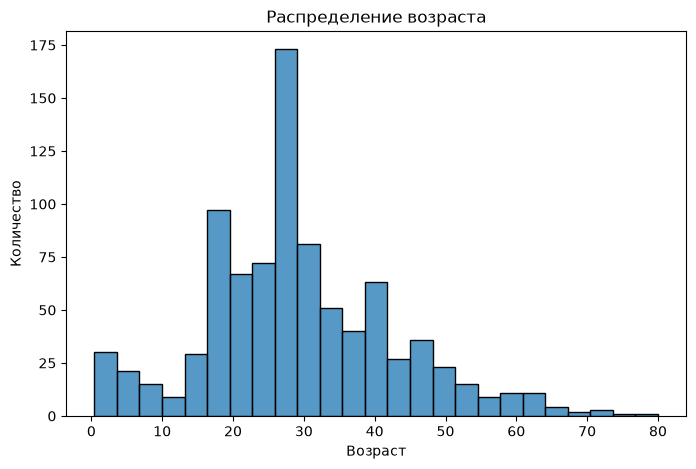

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))       # размер фигуры
sns.histplot(data=df, x="Age")
plt.title("Распределение возраста")
plt.xlabel("Возраст")
plt.ylabel("Количество")
plt.show()

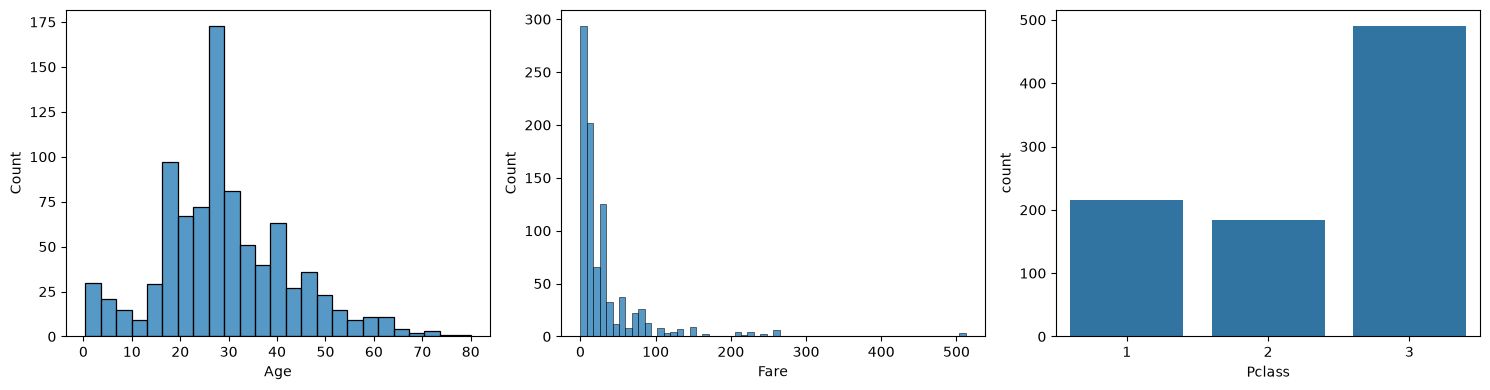

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(data=df, x="Age", ax=axes[0])
sns.histplot(data=df, x="Fare", ax=axes[1])
sns.countplot(data=df, x="Pclass", ax=axes[2])
plt.tight_layout()               # убирает наложение подписей
plt.show()

<Axes: xlabel='Age', ylabel='Density'>

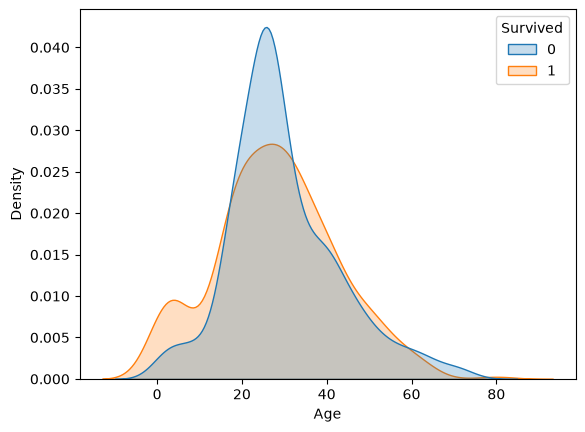

In [80]:
sns.kdeplot(data=df, x="Age", hue="Survived", fill=True, common_norm=False)

<Axes: xlabel='Sex', ylabel='Pclass'>

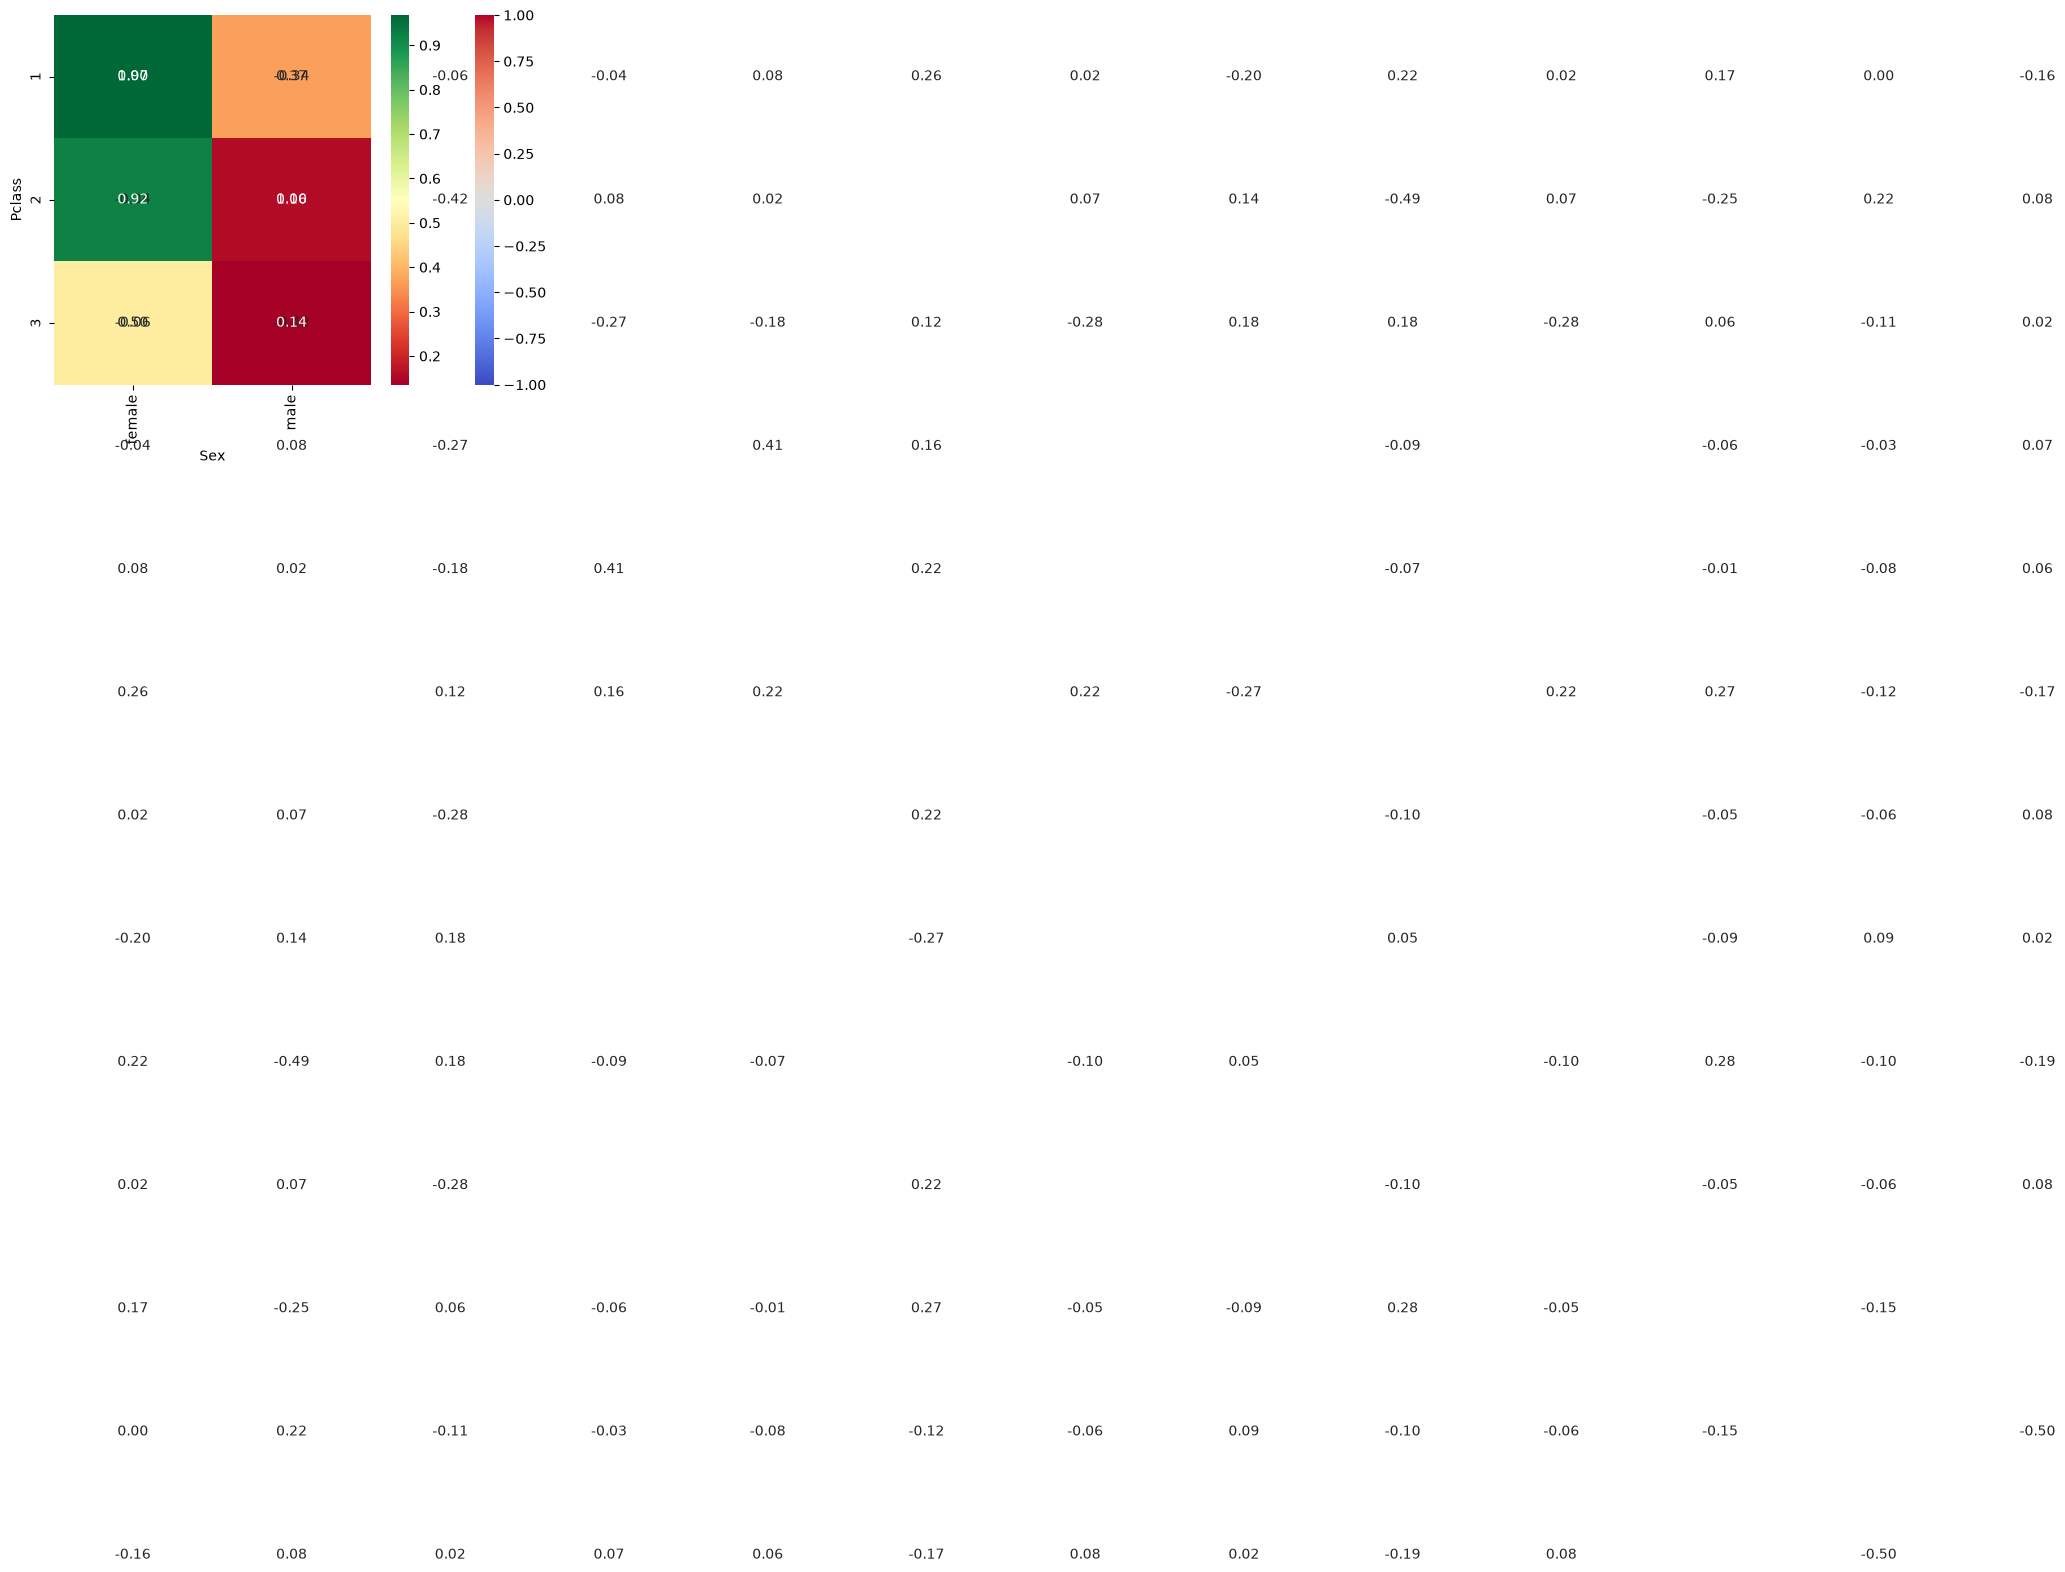

In [81]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

pivot = pd.pivot_table(df, values="Survived", index="Pclass", columns="Sex", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn")